<a href="https://colab.research.google.com/github/dikshitakullolli-123/diabetes-predictor/blob/main/taxi_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Initial import of google_ml_edu was here, moved to main import block for consistency.

In [2]:
pip install numpy

In [3]:
# Original pip install commands moved to separate cells for correct execution.

In [4]:
!pip install pandas

In [5]:
!pip install tensorflow

In [6]:
!pip install keras

In [7]:
!pip install scikit-learn

In [8]:
!pip install matplotlib

In [10]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
import sklearn
import matplotlib
import ml_edu # This package was not found, please verify the name.

In [1]:
pip install google-ml-edu==0.1.3

In [12]:
# The !pip install google_ml_edu was here, but has been handled by cell IR0VgngP9uQ4.
# The import statements are now consolidated in cell 7jBoOHnA96xz.

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
import sklearn
import matplotlib
import ml_edu.experiment
import ml_edu.results
import plotly.express as px

In [14]:
pip show google_ml_edu

Name: google-ml-edu
Version: 0.1.3
Summary: Python utilities for colabs and other learning material from the Google Machine Learning Education team.
Home-page: https://github.com/google/ml-edu
Author: 
Author-email: ml-edu authors <ml-edu-lib@google.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: keras, matplotlib, numpy, pandas, tensorflow
Required-by: 


In [4]:
chicago_taxi_dataset=pd.read_csv("https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv")
chicago_taxi_dataset.head()

,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.0,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.0,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.0,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.0,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.0,0.0,0.0,0.0,10.00,Cash,Flash Cab


In [5]:
chicago_taxi_dataset.head(200)

,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.00,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.00,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.00,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.00,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.00,0.0,0.0,0.0,10.00,Cash,Flash Cab
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,05/17/2022 5:45:00 PM,05/17/2022 6:00:00 PM,17.75,821,1.13,5.0,1.703108e+10,1.703108e+10,8.0,8.0,9.00,2.06,22.9,0.0,0.0,11.06,Mobile,Blue Ribbon Taxi Association
196,05/17/2022 11:45:00 PM,05/17/2022 11:45:00 PM,23.75,414,0.57,5.0,NaN,NaN,32.0,32.0,6.00,0.00,0.0,0.0,0.0,6.00,Cash,Flash Cab
197,05/17/2022 3:45:00 PM,05/17/2022 4:00:00 PM,15.75,886,1.22,5.0,1.703108e+10,1.703184e+10,8.0,8.0,9.00,0.00,0.0,0.0,0.0,9.00,Cash,City Service
198,05/17/2022 5:00:00 PM,05/17/2022 5:15:00 PM,17.00,1219,1.68,5.0,1.703183e+10,1.703108e+10,28.0,8.0,9.00,2.07,23.0,0.0,0.0,11.07,Mobile,Sun Taxi


In [6]:
print('total number of rows : {0}\n\n'.format(len(chicago_taxi_dataset.index)))
chicago_taxi_dataset.describe(include='all')

total number of rows : 31694




,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
count,31694,31694,31694.000000,31694.000000,31694.000000,31694.000000,1.325900e+04,1.402300e+04,28477.000000,28199.000000,31694.000000,31694.000000,31694.000000,31694.000000,31694.000000,31694.000000,31694,31694
unique,193,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,31
top,05/17/2022 5:00:00 PM,05/17/2022 6:00:00 PM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Credit Card,Flash Cab
freq,331,343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14142,7887
mean,NaN,NaN,14.185635,1319.796397,8.289463,20.256544,1.703153e+10,1.703140e+10,35.562138,25.550410,23.905210,3.246130,12.965785,0.002744,2.410468,29.755053,NaN,NaN
std,NaN,NaN,5.159454,928.932873,7.265672,11.110390,3.827747e+05,3.408106e+05,26.421367,20.349707,16.970022,4.284567,15.517765,0.164343,5.805087,23.145537,NaN,NaN
min,NaN,NaN,0.000000,60.000000,0.500000,4.000000,1.703102e+10,1.703101e+10,1.000000,1.000000,3.250000,0.000000,0.000000,0.000000,0.000000,3.250000,NaN,NaN
25%,NaN,NaN,10.500000,548.000000,1.720000,11.000000,1.703108e+10,1.703108e+10,8.000000,8.000000,9.000000,0.000000,0.000000,0.000000,0.000000,10.750000,NaN,NaN
50%,NaN,NaN,14.750000,1081.000000,5.920000,17.600000,1.703132e+10,1.703132e+10,32.000000,28.000000,18.750000,2.000000,12.200000,0.000000,0.000000,21.700000,NaN,NaN
75%,NaN,NaN,18.000000,1888.000000,14.500000,27.500000,1.703198e+10,1.703184e+10,59.000000,32.000000,38.750000,5.000000,20.800000,0.000000,4.000000,48.265000,NaN,NaN


In [7]:
max_fare=chicago_taxi_dataset['FARE'].max()
print("What is the maximum fare     Answer:${fare:.2f}".format(fare=max_fare))

What is the maximum fare     Answer:$159.25


In [8]:
mean_distance=chicago_taxi_dataset['TRIP_MILES'].mean()
print("What is the average distance   Answer:{mean:.4f} miles".format(mean=mean_distance))


What is the average distance   Answer:8.2895 miles


In [9]:
num_unique_companies=chicago_taxi_dataset['COMPANY'].nunique()
print("How many cab companies are in the dataset?     Answer: {num_companies}".format(num_companies=num_unique_companies))

How many cab companies are in the dataset?     Answer: 31


In [10]:
most_freq_payment_type=chicago_taxi_dataset['PAYMENT_TYPE'].value_counts().idxmax()
print("What is the most frequent payment type?     Answer: {payment_type}".format(payment_type=most_freq_payment_type))


What is the most frequent payment type?     Answer: Credit Card


In [11]:
missing_value=chicago_taxi_dataset.isnull().sum().sum()
print("Are there any missing values?     Answer:", "No" if missing_value.sum() == 0 else "Yes")

Are there any missing values?     Answer: Yes


In [12]:
chicago_taxi_dataset.corr(numeric_only=True)

,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL
TRIP_START_HOUR,1.000000,0.008696,-0.038388,-0.095969,0.074479,-0.168438,0.011324,-0.128613,-0.037789,0.037504,0.062828,0.006833,0.023362,-0.015010
TRIP_SECONDS,0.008696,1.000000,0.800855,0.301209,0.493533,0.141334,0.437223,0.195731,0.830292,0.433930,-0.084294,0.008326,0.273981,0.759248
TRIP_MILES,-0.038388,0.800855,1.000000,0.748004,0.593248,0.162535,0.591359,0.249433,0.975344,0.575374,-0.049594,0.020540,0.491254,0.947163
TRIP_SPEED,-0.095969,0.301209,0.748004,1.000000,0.559719,0.152314,0.499278,0.222068,0.695734,0.421333,-0.057886,0.021274,0.434519,0.698774
PICKUP_CENSUS_TRACT,0.074479,0.493533,0.593248,0.559719,1.000000,-0.040886,0.886250,-0.078281,0.586485,0.488247,0.013572,0.034315,0.397197,0.602521
DROPOFF_CENSUS_TRACT,-0.168438,0.141334,0.162535,0.152314,-0.040886,1.000000,-0.018737,0.776753,0.159137,0.072690,-0.022817,0.024831,0.039611,0.142989
PICKUP_COMMUNITY_AREA,0.011324,0.437223,0.591359,0.499278,0.886250,-0.018737,1.000000,0.018548,0.567285,0.455393,0.019191,0.022610,0.458703,0.618728
DROPOFF_COMMUNITY_AREA,-0.128613,0.195731,0.249433,0.222068,-0.078281,0.776753,0.018548,1.000000,0.252030,0.031585,-0.089435,0.011812,-0.013395,0.206128
FARE,-0.037789,0.830292,0.975344,0.695734,0.586485,0.159137,0.567285,0.252030,1.000000,0.544654,-0.070979,0.019363,0.462853,0.952132
TIPS,0.037504,0.433930,0.575374,0.421333,0.488247,0.072690,0.455393,0.031585,0.544654,1.000000,0.550059,0.009655,0.441185,0.700184


In [19]:
def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric]
) -> keras.Model:

        inputs={name: keras.Input(name=name, shape=(1,)) for name in settings.input_features}

        concantenated_inputs=keras.layers.concatenate(list(inputs.values()))
        output=keras.layers.Dense(1)(concantenated_inputs)

        model=keras.Model(inputs, output)

        model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
                  loss="mean_squared_error",
                  metrics=metrics)

        return model


def train_model(
    experiment_name:str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings
) -> ml_edu.experiment.Experiment:


    features={name: dataset[name].values for name in settings.input_features}
    label=dataset[label_name].values
    history=model.fit(x=features,
                      y=label,
                      batch_size=settings.batch_size,
                      epochs=settings.number_epochs)

    return ml_edu.experiment.Experiment(
        name=experiment_name,
        settings=settings,
        model=model,
        epochs=history.epoch,
        metrics_history=pd.DataFrame(history.history),
    )
print("SUCCESS:defining linear regression functions complete")

SUCCESS:defining linear regression functions complete


Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 533.8247 - rmse: 23.1046
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 256.5887 - rmse: 16.0184
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 86.9712 - rmse: 9.3258  
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 21.6117 - rmse: 4.6488
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16.2921 - rmse: 4.0364
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.3486 - rmse: 3.9177
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.7295 - rmse: 3.8379
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.3725 - rmse: 3.7911
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.1805 - rmse: 3.7657
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.0950 - rmse: 3.7543
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.0618 - rmse: 3.7499
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.0423 - rmse: 3.

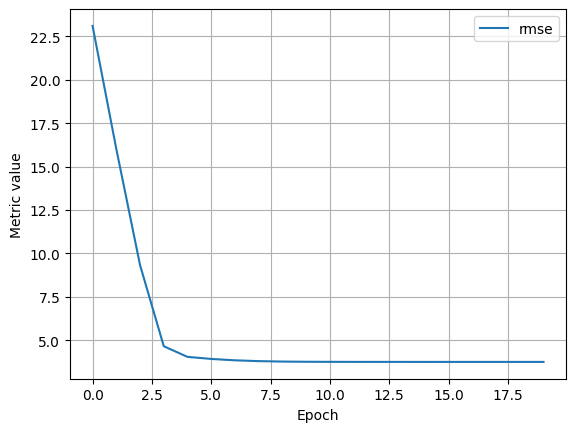

In [21]:
#Training the model with one feature
settings_1=ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=50,
    input_features=["TRIP_MILES"],
)

metrics=[keras.metrics.RootMeanSquaredError('rmse')]
model_1=create_model(settings_1,metrics)
experiment_1=train_model('one_feature',model_1,chicago_taxi_dataset,'FARE',settings_1)
ml_edu.results.plot_experiment_metrics(experiment_1,['rmse'])
ml_edu.results.plot_model_predictions(experiment_1,chicago_taxi_dataset,'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 399.4039 - rmse: 19.9851
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 169.5047 - rmse: 13.0194
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 46.2636 - rmse: 6.8017
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 17.7124 - rmse: 4.2086
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16.3419 - rmse: 4.0425
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.4008 - rmse: 3.9244
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.7615 - rmse: 3.8421
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.3811 - rmse: 3.7922
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.1913 - rmse: 3.7671
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.0974 - rmse: 3.7546
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.0621 - rmse: 3.7499
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.0428 - rmse: 3.74

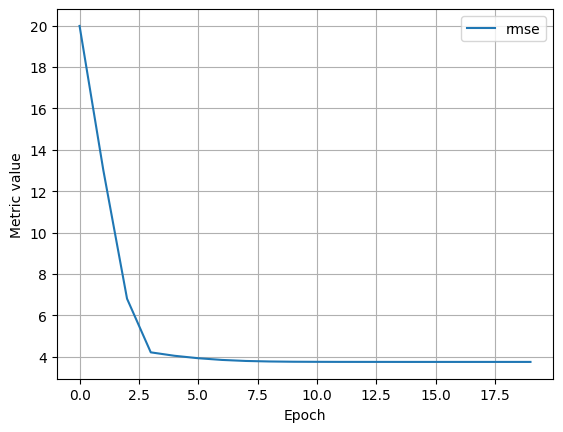

In [24]:
#experiment_2
settings_2=ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES']
)

metrics=[keras.metrics.RootMeanSquaredError(name='rmse')]
model_2=create_model(settings_2,metrics)
experiment_2=train_model('one_feature_hyper',model_2,chicago_taxi_dataset,'FARE',settings_2)
ml_edu.results.plot_experiment_metrics(experiment_2,['rmse'])
ml_edu.results.plot_model_predictions(experiment_2,chicago_taxi_dataset,'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 217.2604 - rmse: 14.7398
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 85.9176 - rmse: 9.2692  
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 30.5450 - rmse: 5.5268
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 15.8103 - rmse: 3.9762
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.1491 - rmse: 3.8922
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.9562 - rmse: 3.8673
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.7943 - rmse: 3.8463
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.6525 - rmse: 3.8279
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.5416 - rmse: 3.8133
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.4501 - rmse: 3.8013
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.3755 - rmse: 3.7915
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.3111 - rmse: 3.78

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


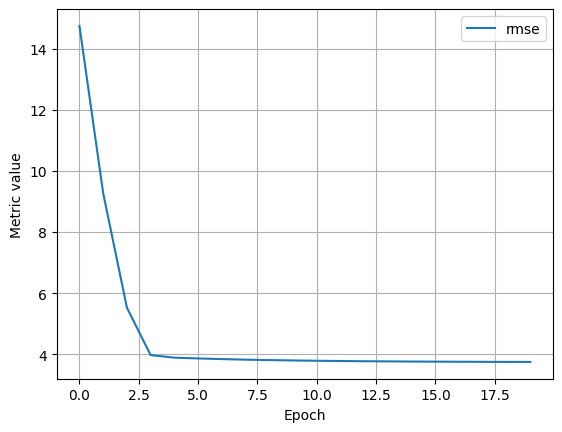

In [25]:
#Training the model with 2 features

settings_3=ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES','TRIP_START_HOUR']
)

metrics=[keras.metrics.RootMeanSquaredError(name='rmse')]
model_3=create_model(settings_3,metrics)
experiment_3=train_model('two_features',model_3,chicago_taxi_dataset,'FARE',settings_3)

ml_edu.results.plot_experiment_metrics(experiment_3,['rmse'])
ml_edu.results.plot_model_predictions(experiment_3,chicago_taxi_dataset,'FARE')

--------------------------------------------------------------------------------
|                                 PREDICTIONS                                  |
--------------------------------------------------------------------------------
   PREDICTED_FARE OBSERVED_FARE L1_LOSS  TRIP_MILES TRIP_START_HOUR
0           $6.25         $4.75   $1.50        0.60           16.75
1           $8.18         $9.00   $0.82        1.57            7.75
2          $78.82        $77.50   $1.32       32.41           13.50
3          $52.77        $49.17   $3.60       21.00           14.25
4          $15.69        $15.00   $0.69        4.65           22.50
5          $31.29        $32.25   $0.96       11.61           13.25
6          $10.45        $73.27  $62.82        2.49           13.00
7          $30.76        $29.50   $1.26       11.28           20.25
8           $8.90         $8.25   $0.65        1.74           18.25
9           $9.83         $9.00   $0.83        2.30            7.25
10       

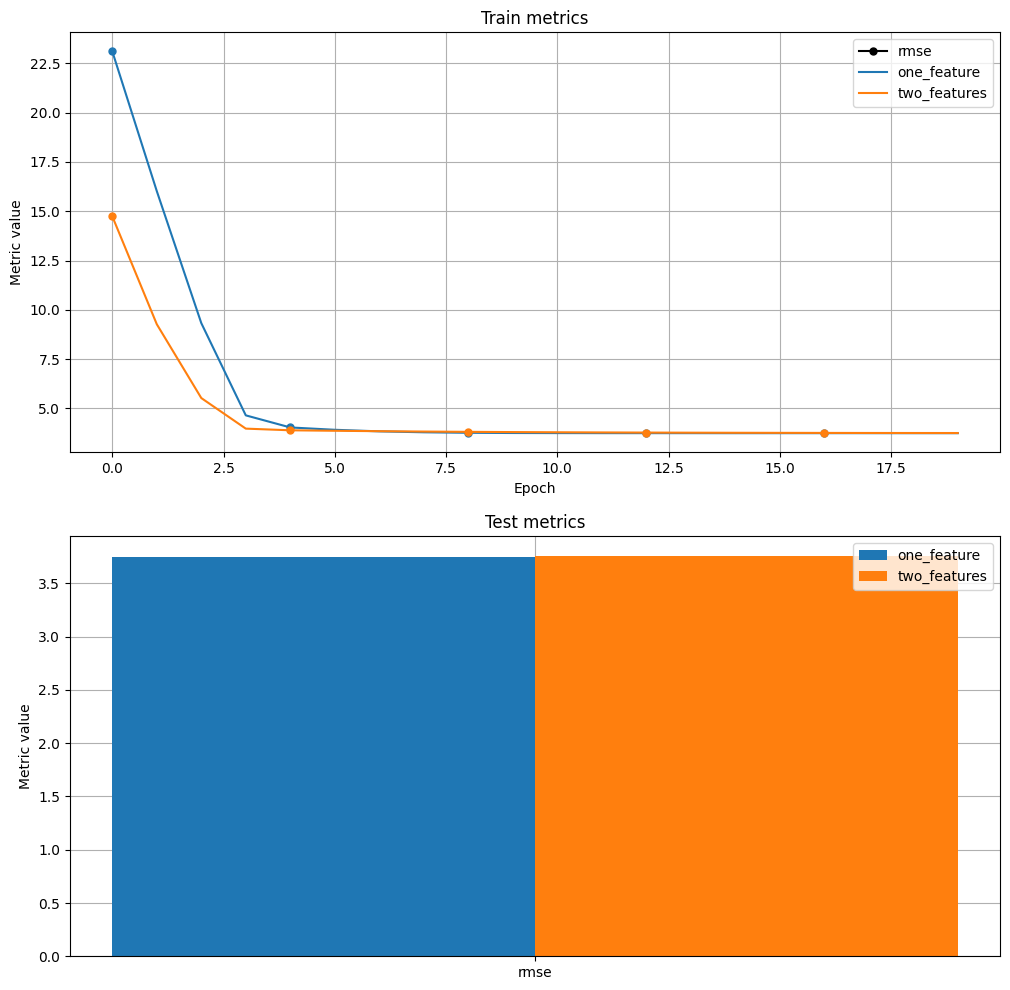

In [28]:
#Compare the both experiments
ml_edu.results.compare_experiment([experiment_1,experiment_3],['rmse'],chicago_taxi_dataset,chicago_taxi_dataset['FARE'].values)

def format_currency(x):
  return "${:.2f}".format(x)

def build_batch(df,batch_size):
  batch=df.sample(n=batch_size).copy()
  batch.set_index(np.arange(batch_size),inplace=True)
  # Removed the line below as it converts 'FARE' to string too early.
  # batch['FARE']=batch['FARE'].apply(format_currency)
  return batch

def predict_fare(model,df,features,label,batch_size=50):
  batch=build_batch(df,batch_size)
  predicted_values=model.predict_on_batch(x={name:batch[name].values for name in features})
  data={"PREDICTED_FARE":[],"OBSERVED_FARE":[],"L1_LOSS":[],features[0]:[],features[1]:[]}

  for i in range(batch_size):
    predicted=predicted_values[i][0]
    observed=batch.at[i,label]
    data["PREDICTED_FARE"].append(format_currency(predicted))
    data["OBSERVED_FARE"].append(format_currency(observed))
    data["L1_LOSS"].append(format_currency(abs(observed-predicted)))
    data[features[0]].append(batch.at[i,features[0]])
    data[features[1]].append("{:.2f}".format(batch.at[i,features[1]]))

  output_df=pd.DataFrame(data)
  return output_df

def show_predictions(output):
  header="-"*80
  banner=header+"\n"+"|"+"PREDICTIONS".center(78)+"|"+"\n"+header

  print(banner)
  print(output)
  return


#Make predictions
output=predict_fare(experiment_3.model,chicago_taxi_dataset,settings_3.input_features,'FARE')
show_predictions(output)
